In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

sys.path.append(str(Path("../pricers").resolve()))

from black76 import black76_call, call_spread_price

In [3]:
ticker = "SI=F"
start_date = "2024-01-01"

si = yf.download(ticker, start=start_date, auto_adjust=False, progress=False)
si.columns = [col[0] if isinstance(col, tuple) else col for col in si.columns]
si = si[["Close"]].rename(columns={"Close": "close"}).dropna()

si.tail()

,close
Date,
2026-05-05,73.108002
2026-05-06,76.810997
2026-05-07,79.700996
2026-05-08,80.394997
2026-05-11,80.745003


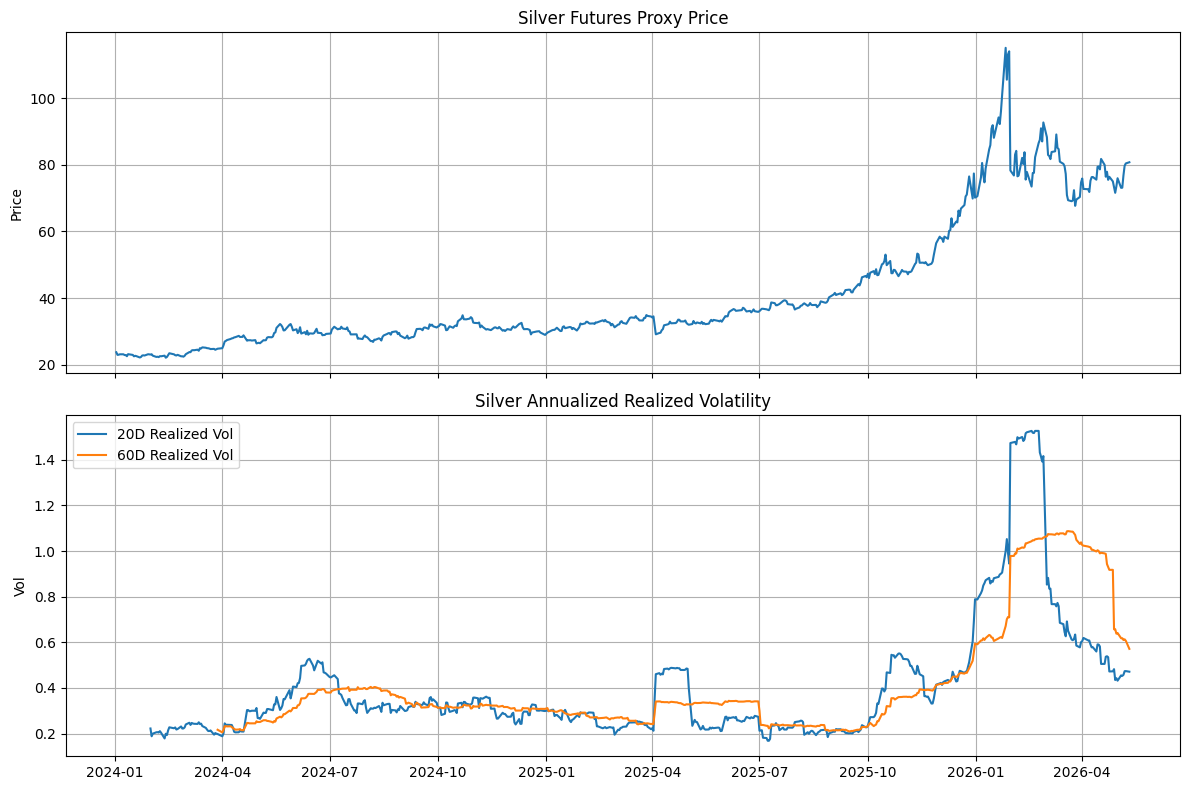

In [4]:
si["ret"] = si["close"].pct_change()
si["rv_20"] = si["ret"].rolling(20).std() * np.sqrt(252)
si["rv_60"] = si["ret"].rolling(60).std() * np.sqrt(252)

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax[0].plot(si.index, si["close"])
ax[0].set_title("Silver Futures Proxy Price")
ax[0].set_ylabel("Price")
ax[0].grid(True)

ax[1].plot(si.index, si["rv_20"], label="20D Realized Vol")
ax[1].plot(si.index, si["rv_60"], label="60D Realized Vol")
ax[1].set_title("Silver Annualized Realized Volatility")
ax[1].set_ylabel("Vol")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

In [5]:
F = float(si["close"].iloc[-1])
K1 = round(F)
K2 = round(F + 3)
T = 14 / 365
r = 0.04
sigma = float(si["rv_20"].iloc[-1])

print("F:", F)
print("K1:", K1)
print("K2:", K2)
print("T:", T)
print("r:", r)
print("sigma:", sigma)

F: 80.74500274658203
K1: 81
K2: 84
T: 0.038356164383561646
r: 0.04
sigma: 0.4711208125169618


In [6]:
long_call = black76_call(F, K1, T, r, sigma)
short_call = black76_call(F, K2, T, r, sigma)
spread_price = call_spread_price(F, K1, K2, T, r, sigma)

print("Long call price:", round(long_call, 4))
print("Short call price:", round(short_call, 4))
print("Call spread price:", round(spread_price, 4))

Long call price: 2.8457
Short call price: 1.6746
Call spread price: 1.1711


In [7]:
max_payoff = K2 - K1
max_profit = max_payoff - spread_price
max_loss = spread_price
breakeven = K1 + spread_price

print("Max payoff:", round(max_payoff, 4))
print("Max profit:", round(max_profit, 4))
print("Max loss:", round(max_loss, 4))
print("Breakeven:", round(breakeven, 4))

Max payoff: 3
Max profit: 1.8289
Max loss: 1.1711
Breakeven: 82.1711


In [8]:
si["abs_move"] = si["close"].diff().abs()
si["move_5d"] = (si["close"] - si["close"].shift(5)).abs()

avg_1d_move_20 = si["abs_move"].rolling(20).mean().iloc[-1]
avg_5d_move_20 = si["move_5d"].rolling(20).mean().iloc[-1]
max_5d_move_60 = si["move_5d"].rolling(60).max().iloc[-1]

print("Average 1D absolute move (20D):", round(avg_1d_move_20, 4))
print("Average 5D absolute move (20D):", round(avg_5d_move_20, 4))
print("Max 5D absolute move (60D):", round(max_5d_move_60, 4))
print("Breakeven move needed:", round(breakeven - F, 4))

Average 1D absolute move (20D): 1.8944
Average 5D absolute move (20D): 3.9736
Max 5D absolute move (60D): 14.01
Breakeven move needed: 1.4261


In [9]:
required_move = breakeven - F

print("Required move / avg 1D move:", round(required_move / avg_1d_move_20, 3))
print("Required move / avg 5D move:", round(required_move / avg_5d_move_20, 3))
print("Required move / max 5D move:", round(required_move / max_5d_move_60, 3))

Required move / avg 1D move: 0.753
Required move / avg 5D move: 0.359
Required move / max 5D move: 0.102


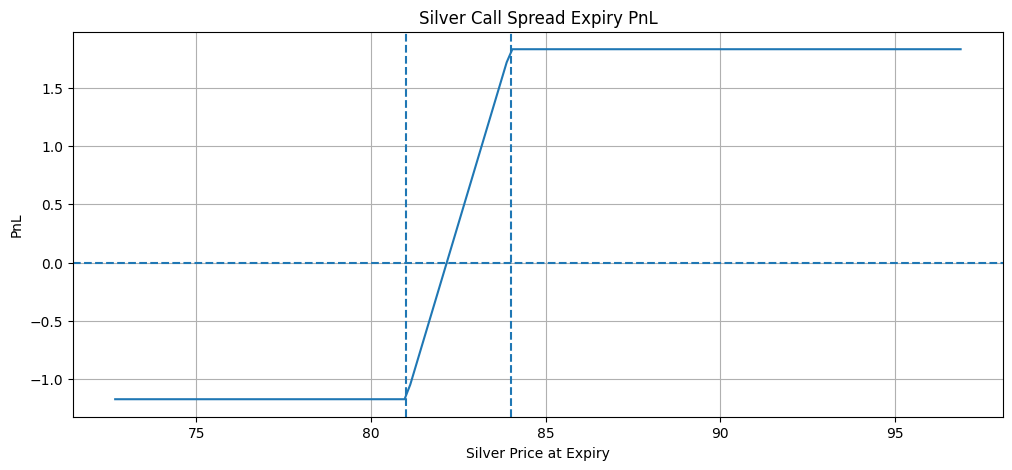

In [10]:
price_grid = np.linspace(F * 0.9, F * 1.2, 150)

pnl = []
for FT in price_grid:
    payoff = max(FT - K1, 0) - max(FT - K2, 0)
    pnl.append(payoff - spread_price)

pnl_df = pd.DataFrame({"F_T": price_grid, "PnL": pnl})

plt.figure(figsize=(12, 5))
plt.plot(pnl_df["F_T"], pnl_df["PnL"])
plt.axhline(0, linestyle="--")
plt.axvline(K1, linestyle="--")
plt.axvline(K2, linestyle="--")
plt.title("Silver Call Spread Expiry PnL")
plt.xlabel("Silver Price at Expiry")
plt.ylabel("PnL")
plt.grid(True)
plt.show()

In [12]:
if required_move < avg_5d_move_20:
    print("Preliminary signal: silver call spread looks attractively priced relative to recent 5D moves.")
else:
    print("Preliminary signal: silver call spread may require a larger-than-average 5D move to work.")

Preliminary signal: silver call spread looks attractively priced relative to recent 5D moves.


In [13]:
for upper_strike in [round(F + 2), round(F + 3), round(F + 4)]:
    spread_price = call_spread_price(F, K1, upper_strike, T, r, sigma)
    max_payoff = upper_strike - K1
    max_profit = max_payoff - spread_price
    breakeven = K1 + spread_price

    print(f"K1={K1}, K2={upper_strike}")
    print("  Spread price:", round(spread_price, 4))
    print("  Max profit:", round(max_profit, 4))
    print("  Breakeven:", round(breakeven, 4))

K1=81, K2=83
  Spread price: 0.8305
  Max profit: 1.1695
  Breakeven: 81.8305
K1=81, K2=84
  Spread price: 1.1711
  Max profit: 1.8289
  Breakeven: 82.1711
K1=81, K2=85
  Spread price: 1.4658
  Max profit: 2.5342
  Breakeven: 82.4658
